# Exploratory Data Analysis of Payment Transactions
## Statistical Profiling, Temporal Dependencies, Error Taxonomies, and Incident Discovery

---

### Overview
This notebook provides a deep empirical analysis of 1,000,000 payment transactions.
It incorporates all foundational investigations across multiple dimensions:
1. Data Structure, Memory Footprint, and Physical Invariants
2. Time Dependencies, Latency Bottlenecks, and Diurnal Heatmaps
3. Multi-Currency Normalization, Exchange Rates, and Outlier Bounds
4. Order Type Cross-Tabulations and Categorical Interactions
5. Refund Dynamics, Over-Refund Anomalies, and August Incident
6. Bank Routing, Entity Failure Rates, and Compromised Bank 777
7. Error Code Categories and Longitudinal Trends
8. User Frequency, Inter-Arrival Velocity, and Bot Bursts
9. Geo-Security, Cross-Border Mismatch, and 3D-Secure Effectiveness


In [30]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

data_path = Path('data/transactions.csv') if Path('data/transactions.csv').exists() else Path('../data/transactions.csv')
data = pd.read_csv(data_path)
print(f'Total records: {len(data):,}, Total features: {data.shape[1]}')
print(f'Memory usage: {data.memory_usage(deep=True).sum() / (1024**2):.2f} MB')


Total records: 1,000,000, Total features: 18
Memory usage: 582.91 MB


## 1. Schema Validation, Timestamps, and Physical Invariant Audit
We parse temporal columns into UTC datetime, derive operational processing latencies, and check physical constraints.


In [31]:
data['created_at'] = pd.to_datetime(data['created_at'], utc=True)
data['processed_at'] = pd.to_datetime(data['processed_at'], utc=True)
data['latency_sec'] = (data['processed_at'] - data['created_at']).dt.total_seconds()
data['date'] = data['created_at'].dt.date
data['create_hour'] = data['created_at'].dt.hour
data['process_hour'] = data['processed_at'].dt.hour
data['create_day_of_week'] = data['created_at'].dt.day_name()
data['process_day_of_week'] = data['processed_at'].dt.day_name()
data['is_failed'] = (data['status'] == 'fail').astype(int)
data['has_refund'] = data['has_refund'].astype(bool)
data['refunded_amount_clean'] = data['refunded_amount'].fillna(0)

schema_table = pd.DataFrame({
    'Feature': data.columns,
    'Non-Null Count': data.notnull().sum().values,
    'Null Count': data.isnull().sum().values,
    'Null Pct (%)': (data.isnull().sum().values / len(data) * 100).round(2),
    'Data Type': [str(t) for t in data.dtypes.values]
})
print(schema_table.to_string(index=False))


              Feature  Non-Null Count  Null Count  Null Pct (%)           Data Type
           created_at         1000000           0          0.00 datetime64[us, UTC]
             order_id         1000000           0          0.00               int64
         processed_at         1000000           0          0.00 datetime64[us, UTC]
           order_type         1000000           0          0.00                 str
              user_id         1000000           0          0.00               int64
           ip_country         1000000           0          0.00                 str
             currency         1000000           0          0.00                 str
               amount         1000000           0          0.00             float64
       payment_method         1000000           0          0.00                 str
   order_payment_type          599474      400526         40.05                 str
          bin_country         1000000           0          0.00             

In [32]:
neg_lat = int((data['latency_sec'] < 0).sum())
non_pos_amt = int((data['amount'] <= 0).sum())
dup_orders = int(data['order_id'].duplicated().sum())
null_users = int(data['user_id'].isnull().sum())

inv_df = pd.DataFrame({
    'Physical Invariant': [
        'Non-Negative Processing Latency (processed_at >= created_at)',
        'Strictly Positive Amount (amount > 0)',
        'Unique Order IDs (order_id uniqueness)',
        'Valid User Association (user_id not null)'
    ],
    'Violations Detected': [neg_lat, non_pos_amt, dup_orders, null_users],
    'Integrity Status': ['Pass' if v == 0 else 'Fail' for v in [neg_lat, non_pos_amt, dup_orders, null_users]]
})
print(inv_df.to_string(index=False))


                                          Physical Invariant  Violations Detected Integrity Status
Non-Negative Processing Latency (processed_at >= created_at)                    0             Pass
                       Strictly Positive Amount (amount > 0)                    0             Pass
                      Unique Order IDs (order_id uniqueness)                    0             Pass
                   Valid User Association (user_id not null)                    0             Pass


## 2. Time Dependencies, Latency Bottlenecks, and Diurnal Heatmaps
We analyze processing latency across payment gateways (PSP) and examine hourly/weekly transaction intensities.


In [33]:
psp_lat_stats = data.groupby('psp_id')['latency_sec'].agg(
    Count='count',
    Mean_Latency=('mean'),
    Median_Latency=('median'),
    Std_Latency=('std'),
    P90_Latency=(lambda x: np.percentile(x, 90)),
    P95_Latency=(lambda x: np.percentile(x, 95)),
    P99_Latency=(lambda x: np.percentile(x, 99)),
    Max_Latency=('max')
).reset_index()
print(psp_lat_stats.round(2).to_string(index=False))

long_processing = data[data['latency_sec'] > 3000]
print(f'\nExtreme processing delays (>3000s): {len(long_processing):,} transactions ({len(long_processing)/len(data)*100:.2f}%)')
print('PSP Breakdown for >3000s latency:')
print(long_processing['psp_id'].value_counts())


   psp_id  Count  Mean_Latency  Median_Latency  Std_Latency  P90_Latency  P95_Latency  P99_Latency  Max_Latency
psp_alpha 334013          6.00             6.0         2.58         10.0         10.0        10.00         10.0
 psp_beta 333027          5.99             6.0         2.58         10.0         10.0        10.00         10.0
psp_gamma 332960         94.19             6.0       697.50         10.0         10.0      4997.41       7199.0

Extreme processing delays (>3000s): 5,433 transactions (0.54%)
PSP Breakdown for >3000s latency:
psp_id
psp_gamma    5433
Name: count, dtype: int64


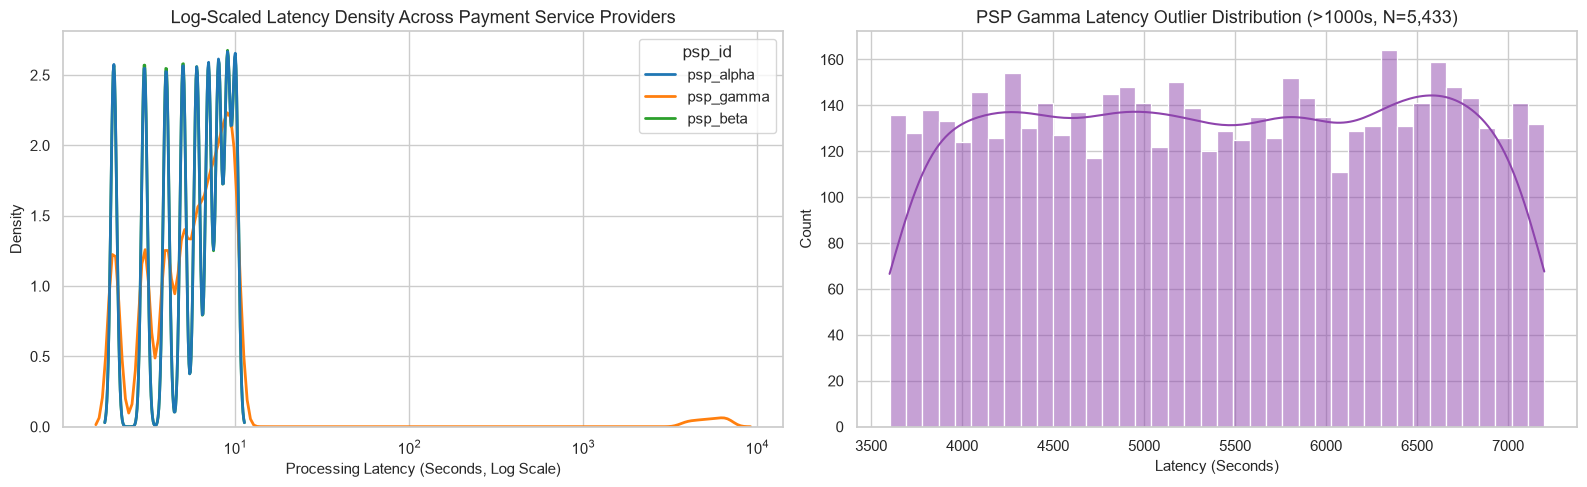

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.kdeplot(data=data, x='latency_sec', hue='psp_id', common_norm=False, log_scale=True, ax=axes[0], palette='tab10', linewidth=2)
axes[0].set_title('Log-Scaled Latency Density Across Payment Service Providers')
axes[0].set_xlabel('Processing Latency (Seconds, Log Scale)')

gamma_tail = data[(data['psp_id'] == 'psp_gamma') & (data['latency_sec'] > 1000)]
sns.histplot(gamma_tail['latency_sec'], bins=40, ax=axes[1], color='#8e44ad', kde=True)
axes[1].set_title(f'PSP Gamma Latency Outlier Distribution (>1000s, N={len(gamma_tail):,})')
axes[1].set_xlabel('Latency (Seconds)')

plt.tight_layout()
plt.show()


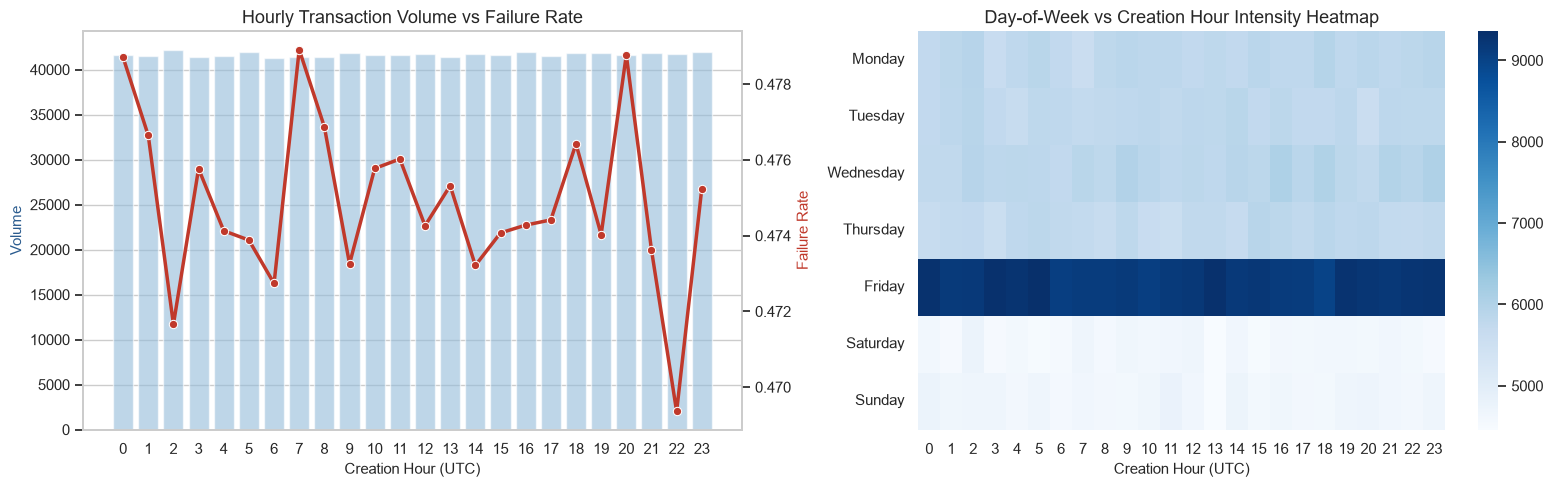

In [35]:
hourly_agg = data.groupby('create_hour').agg(volume=('order_id', 'count'), fail_rate=('is_failed', 'mean')).reset_index()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_intensity = data.pivot_table(index='create_day_of_week', columns='create_hour', values='order_id', aggfunc='count').reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax1 = axes[0]
ax2 = ax1.twinx()
sns.barplot(data=hourly_agg, x='create_hour', y='volume', ax=ax1, color='#88bde6', alpha=0.6)
sns.lineplot(data=hourly_agg, x='create_hour', y='fail_rate', ax=ax2, color='#c0392b', marker='o', linewidth=2.5)
ax1.set_title('Hourly Transaction Volume vs Failure Rate')
ax1.set_xlabel('Creation Hour (UTC)')
ax1.set_ylabel('Volume', color='#2b5c8f')
ax2.set_ylabel('Failure Rate', color='#c0392b')
ax2.grid(False)

sns.heatmap(pivot_intensity, cmap='Blues', ax=axes[1], cbar=True)
axes[1].set_title('Day-of-Week vs Creation Hour Intensity Heatmap')
axes[1].set_xlabel('Creation Hour (UTC)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


## 3. Multi-Currency Normalization and Financial Distribution
We standardize all payment amounts to USD using baseline foreign exchange rates and investigate heavy-tailed distributions.


In [36]:
fx_rates = {
    'USD': 1.0,
    'EUR': 1.08,
    'GBP': 1.27,
    'UAH': 0.024,
    'PLN': 0.25,
    'CAD': 0.74,
    'MXN': 0.055
}
data['amount_usd'] = data['amount'] * data['currency'].map(lambda c: fx_rates.get(str(c).upper(), 1.0))
data['log_amount_usd'] = np.log1p(np.maximum(data['amount_usd'], 0))

currency_summary = data.groupby('currency').agg(
    Volume=('order_id', 'count'),
    Mean_Raw=('amount', 'mean'),
    Median_Raw=('amount', 'median'),
    Mean_USD=('amount_usd', 'mean'),
    Median_USD=('amount_usd', 'median'),
    Std_USD=('amount_usd', 'std')
).reset_index()
currency_summary['Volume Pct (%)'] = (currency_summary['Volume'] / len(data) * 100).round(2)
print(currency_summary.round(2).to_string(index=False))


currency  Volume  Mean_Raw  Median_Raw  Mean_USD  Median_USD  Std_USD  Volume Pct (%)
     CAD  150032     34.72        27.4     25.69       20.28    27.22           15.00
     EUR  119659     23.52        18.4     25.40       19.87    26.97           11.97
     GBP   60159     19.88        15.6     25.25       19.81    26.70            6.02
     MXN   49810    472.07       370.0     25.96       20.35    27.31            4.98
     PLN   59636    101.23        80.4     25.31       20.10    26.35            5.96
     UAH   60233   1055.87       824.0     25.34       19.78    26.43            6.02
     USD  500471     25.51        20.0     25.51       20.00    26.79           50.05


Percentile  Amount USD ($)
      0.1%            0.99
        1%            0.99
        5%            1.00
       25%            9.94
       50%           19.99
       75%           30.52
       90%           50.69
       95%           60.83
       99%          150.00
     99.5%          198.72
     99.9%          202.76


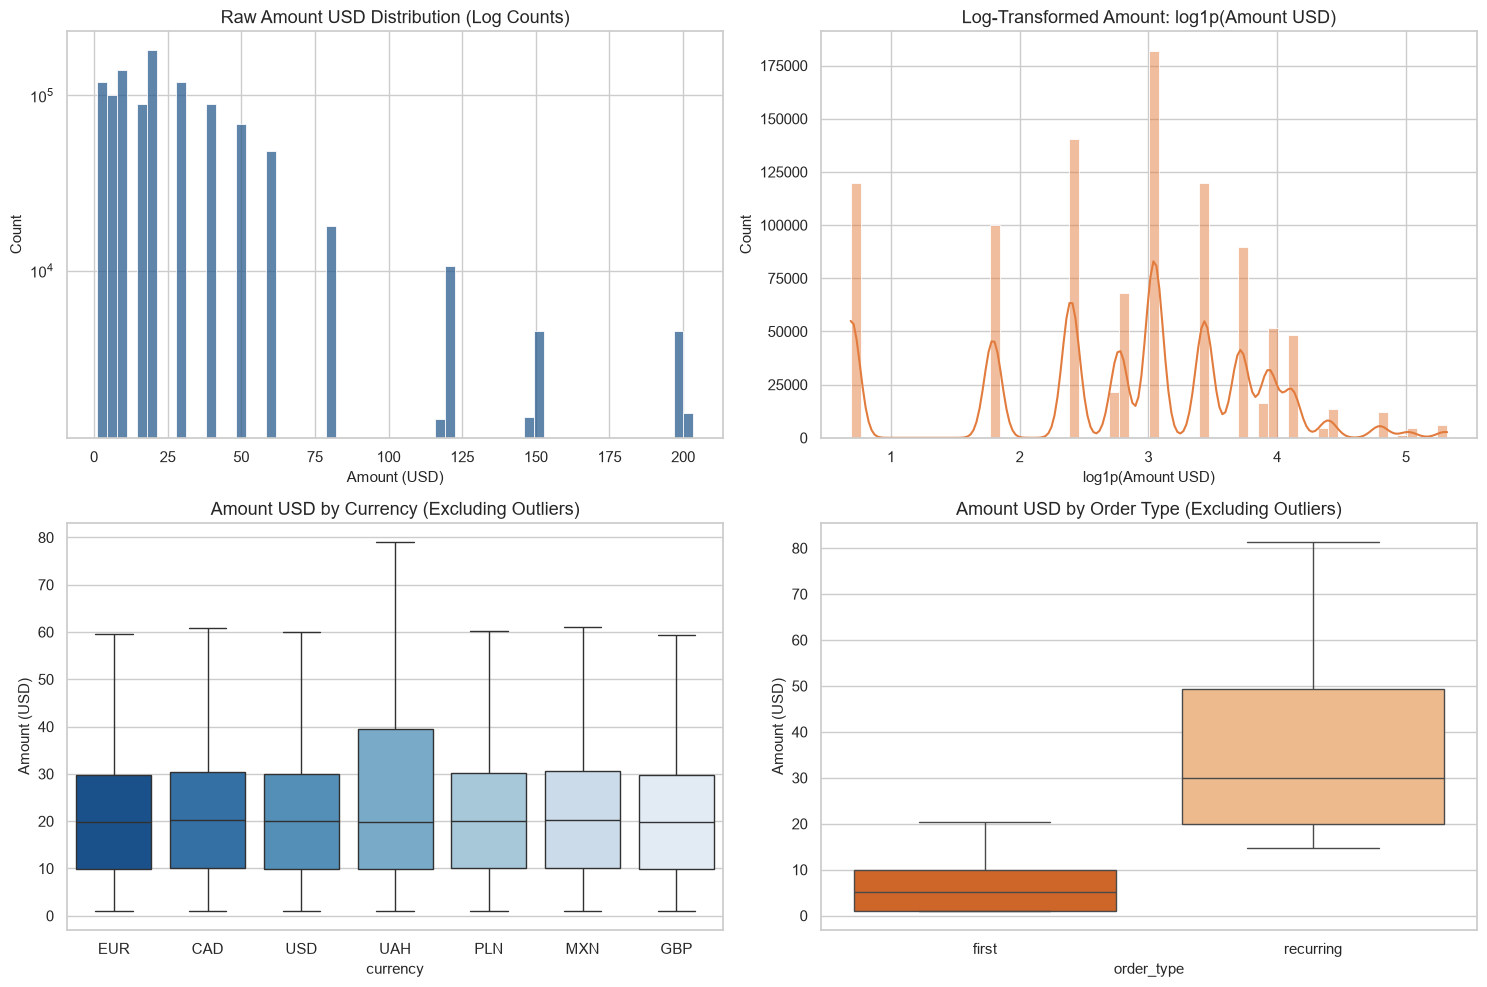

In [37]:
pctiles = [0.1, 1, 5, 25, 50, 75, 90, 95, 99, 99.5, 99.9]
pct_vals = np.percentile(data['amount_usd'], pctiles)
pct_table = pd.DataFrame({
    'Percentile': [f'{p}%' for p in pctiles],
    'Amount USD ($)': [round(v, 2) for v in pct_vals]
})
print(pct_table.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(data['amount_usd'], bins=60, ax=axes[0, 0], color='#2b5c8f', kde=False)
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Raw Amount USD Distribution (Log Counts)')
axes[0, 0].set_xlabel('Amount (USD)')

sns.histplot(data['log_amount_usd'], bins=60, ax=axes[0, 1], color='#e27c3e', kde=True)
axes[0, 1].set_title('Log-Transformed Amount: log1p(Amount USD)')
axes[0, 1].set_xlabel('log1p(Amount USD)')

sns.boxplot(data=data, x='currency', y='amount_usd', ax=axes[1, 0], palette='Blues_r', showfliers=False)
axes[1, 0].set_title('Amount USD by Currency (Excluding Outliers)')
axes[1, 0].set_ylabel('Amount (USD)')

sns.boxplot(data=data, x='order_type', y='amount_usd', ax=axes[1, 1], palette='Oranges_r', showfliers=False)
axes[1, 1].set_title('Amount USD by Order Type (Excluding Outliers)')
axes[1, 1].set_ylabel('Amount (USD)')

plt.tight_layout()
plt.show()


## 4. Order Type Cross-Tabulations and Categorical Interactions
We inspect cross-tabulation relationships between order types and routing features.


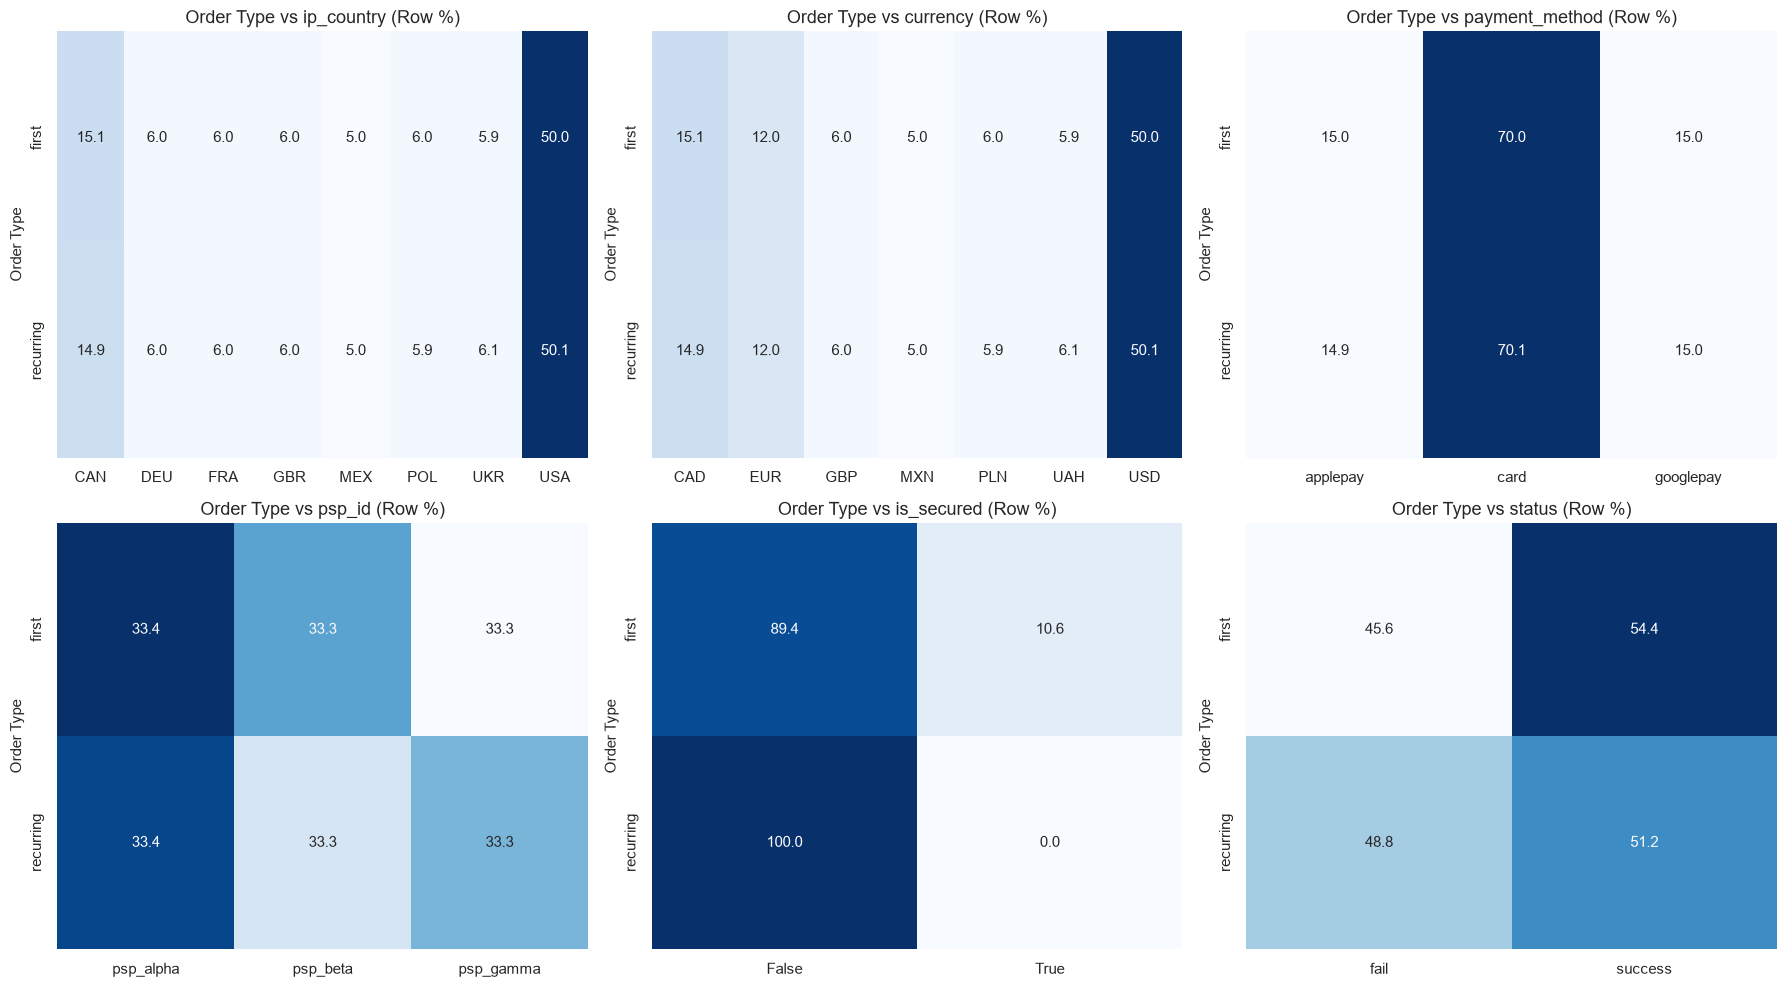

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cat_cols = ['ip_country', 'currency', 'payment_method', 'psp_id', 'is_secured', 'status']
for idx, col in enumerate(cat_cols):
    r, c = divmod(idx, 3)
    ct = pd.crosstab(data['order_type'], data[col], normalize='index') * 100
    sns.heatmap(ct, annot=True, fmt='.1f', cmap='Blues', ax=axes[r, c], cbar=False)
    axes[r, c].set_title(f'Order Type vs {col} (Row %)')
    axes[r, c].set_ylabel('Order Type')
    axes[r, c].set_xlabel('')

plt.tight_layout()
plt.show()


## 5. Refund Dynamics, Over-Refunds, and August PSP Beta Storm
We investigate refund behaviors, identifying over-refund anomalies and the August refund incident on PSP Beta.


In [39]:
data['refund_ratio'] = np.where(data['amount'] > 0, data['refunded_amount_clean'] / data['amount'], 0.0)
data['over_refund'] = data['refunded_amount_clean'] > data['amount']
data['refund_on_fail'] = data['has_refund'] & (data['status'] == 'fail')

ref_stats = pd.DataFrame({
    'Metric': [
        'Total Refunded Transactions',
        'Overall Population Refund Rate (%)',
        'Mean Refunded Amount for Refunded Orders ($)',
        'Over-Refund Incidences (refunded_amount > amount)',
        'Refunds Issued on Failed Orders (status == fail)'
    ],
    'Value': [
        f'{data["has_refund"].sum():,}',
        f'{data["has_refund"].mean() * 100:.2f}%',
        f'${data[data["has_refund"]]["refunded_amount_clean"].mean():.2f}',
        f'{data["over_refund"].sum():,}',
        f'{data["refund_on_fail"].sum():,}'
    ]
})
print(ref_stats.to_string(index=False))


                                           Metric  Value
                      Total Refunded Transactions 37,014
               Overall Population Refund Rate (%)  3.70%
     Mean Refunded Amount for Refunded Orders ($) $63.20
Over-Refund Incidences (refunded_amount > amount)  2,691
 Refunds Issued on Failed Orders (status == fail)  1,299


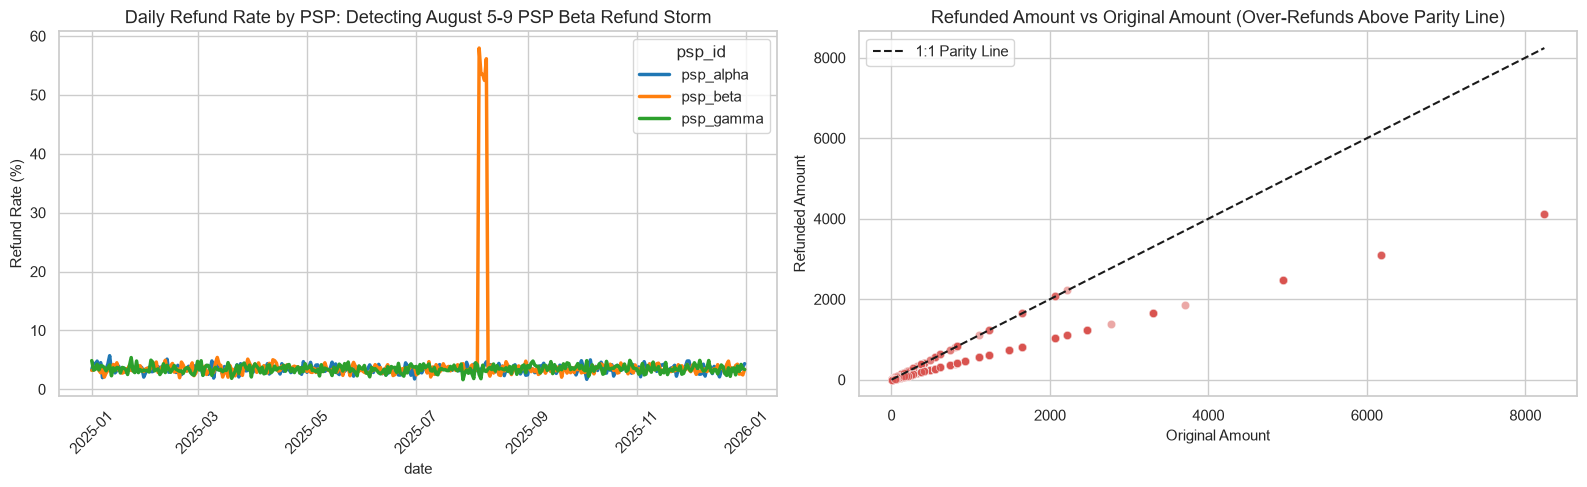

In [40]:
daily_psp_refunds = data.groupby(['date', 'psp_id'])['has_refund'].mean().reset_index()
daily_psp_refunds['Refund Rate (%)'] = daily_psp_refunds['has_refund'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=daily_psp_refunds, x='date', y='Refund Rate (%)', hue='psp_id', ax=axes[0], palette='tab10', linewidth=2.5)
axes[0].set_title('Daily Refund Rate by PSP: Detecting August 5-9 PSP Beta Refund Storm')
axes[0].set_ylabel('Refund Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

data_ref = data[data['has_refund']].copy()
sns.scatterplot(data=data_ref.sample(min(8000, len(data_ref)), random_state=42), x='amount', y='refunded_amount', ax=axes[1], alpha=0.5, color='#d9534f')
axes[1].plot([0, data_ref['amount'].max()], [0, data_ref['amount'].max()], 'k--', linewidth=1.5, label='1:1 Parity Line')
axes[1].set_title('Refunded Amount vs Original Amount (Over-Refunds Above Parity Line)')
axes[1].set_xlabel('Original Amount')
axes[1].set_ylabel('Refunded Amount')
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Bank Routing and Identification of Compromised Bank 777
We compute bank-level performance profiles to identify compromised financial institutions.


In [41]:
bank_profiles = data.groupby('bank_id').agg(
    total_volume=('order_id', 'count'),
    failure_rate=('is_failed', 'mean'),
    refund_rate=('has_refund', 'mean'),
    secured_rate=('is_secured', 'mean'),
    avg_amount_usd=('amount_usd', 'mean')
).reset_index()

bank_777 = data[data['bank_id'] == 777]
print('=== Bank 777 Incident Profile ===')
print(f'Total Transaction Volume: {len(bank_777):,}')
print(f'Failure Rate: {bank_777["is_failed"].mean() * 100:.2f}%')
print(f'3DS Authentication Rate: {bank_777["is_secured"].mean() * 100:.2f}%')
print('Error Code Breakdown for Bank 777:')
print(bank_777['error_code'].value_counts())


=== Bank 777 Incident Profile ===
Total Transaction Volume: 635
Failure Rate: 100.00%
3DS Authentication Rate: 4.09%
Error Code Breakdown for Bank 777:
error_code
4.09    616
2.01     11
3.08      7
2.12      1
Name: count, dtype: int64


## 7. Error Code Taxonomy and Longitudinal Incident Trends
We categorize error codes into functional domains and evaluate daily incident frequencies.


Error Code  Failure Count  Proportion (%)
      3.02         150121           31.61
      3.08          90293           19.01
       3.1          76797           16.17
      2.12          44700            9.41
      2.01          43696            9.20
      3.04          42896            9.03
      4.09          17647            3.72
      4.03           1520            0.32
      3.01           1468            0.31
      0.01           1468            0.31


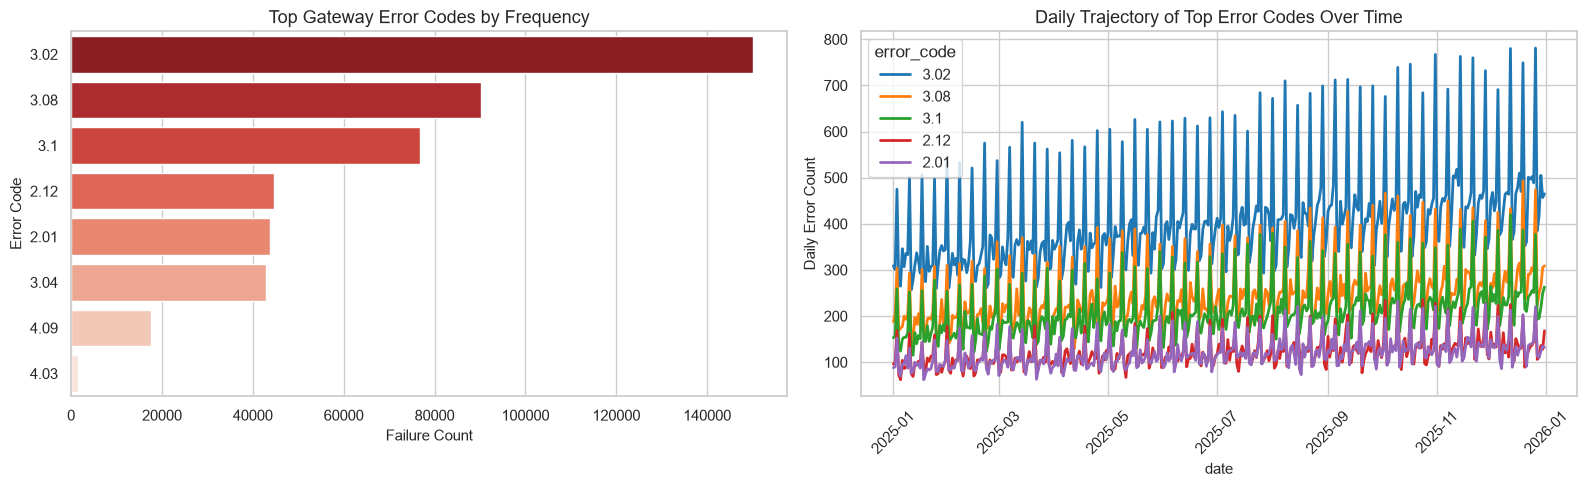

In [42]:
data['error_code_str'] = data['error_code'].astype(str)
data['error_category'] = data['error_code_str'].str.split('.').str[0]

error_agg = data[data['status'] == 'fail']['error_code_str'].value_counts().reset_index()
error_agg.columns = ['Error Code', 'Failure Count']
error_agg['Proportion (%)'] = (error_agg['Failure Count'] / len(data[data['status'] == 'fail']) * 100).round(2)
print(error_agg.head(10).to_string(index=False))

top_errs = error_agg.head(5)['Error Code'].tolist()
daily_err_list = []
for e in top_errs:
    temp = data.groupby('date')['error_code_str'].apply(lambda s: (s == e).sum()).reset_index()
    temp['error_code'] = e
    temp.columns = ['date', 'count', 'error_code']
    daily_err_list.append(temp)
daily_err_df = pd.concat(daily_err_list, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=error_agg.head(8), x='Failure Count', y='Error Code', ax=axes[0], palette='Reds_r', orient='h')
axes[0].set_title('Top Gateway Error Codes by Frequency')

sns.lineplot(data=daily_err_df, x='date', y='count', hue='error_code', ax=axes[1], palette='tab10', linewidth=2)
axes[1].set_title('Daily Trajectory of Top Error Codes Over Time')
axes[1].set_ylabel('Daily Error Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


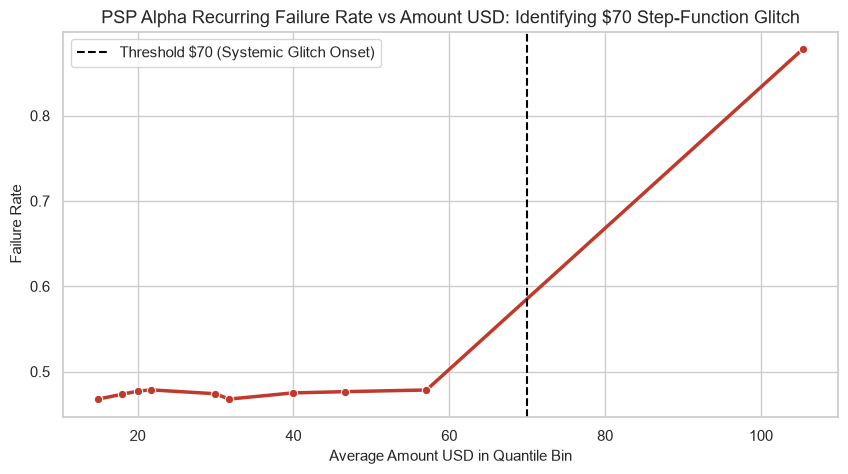

In [43]:
alpha_rec = data[(data['psp_id'] == 'psp_alpha') & (data['order_type'] == 'recurring')].copy()
alpha_rec['amount_quantile'] = pd.qcut(alpha_rec['amount_usd'], q=10, duplicates='drop')
alpha_binned = alpha_rec.groupby('amount_quantile').agg(
    avg_amount=('amount_usd', 'mean'),
    fail_rate=('is_failed', 'mean'),
    volume=('order_id', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=alpha_binned, x='avg_amount', y='fail_rate', ax=ax, marker='o', color='#c0392b', linewidth=2.5)
ax.axvline(70.0, color='black', linestyle='--', label='Threshold $70 (Systemic Glitch Onset)')
ax.set_title('PSP Alpha Recurring Failure Rate vs Amount USD: Identifying $70 Step-Function Glitch')
ax.set_xlabel('Average Amount USD in Quantile Bin')
ax.set_ylabel('Failure Rate')
ax.legend()
plt.show()


## 8. User Behavioral Velocity and Scripted Attack Identification
We calculate user inter-arrival deltas to identify high-velocity card testing and bot attempts.


Total Unique Users: 603,337
Transactions within 60s of previous user order: 2


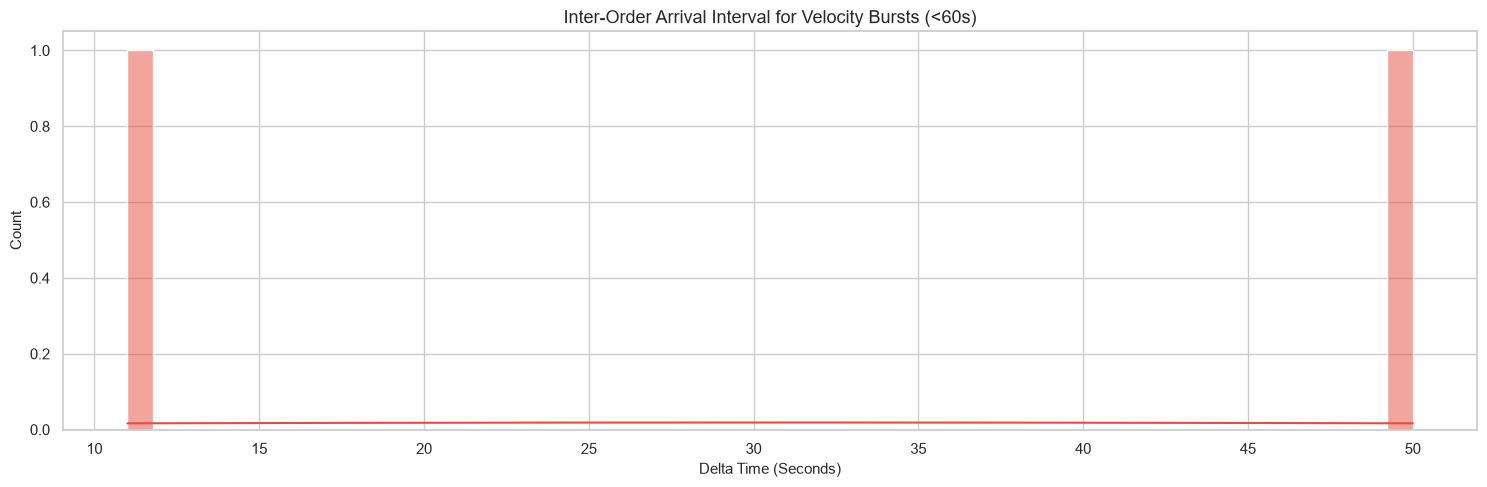

In [48]:
data_sorted = data.sort_values(['user_id', 'created_at']).reset_index(drop=True)
data_sorted['user_prev_time'] = data_sorted.groupby('user_id')['created_at'].shift(1)
data_sorted['inter_order_delta_sec'] = (data_sorted['created_at'] - data_sorted['user_prev_time']).dt.total_seconds()

user_counts = data.groupby('user_id')['order_id'].count()
rapid_attempts = data_sorted[(data_sorted['inter_order_delta_sec'] >= 0.1) & (data_sorted['inter_order_delta_sec'] <= 60.0)]
print(f'Total Unique Users: {len(user_counts):,}')
print(f'Transactions within 60s of previous user order: {len(rapid_attempts):,}')

fig, axes = plt.subplots(1, 1, figsize=(15, 5))

sns.histplot(rapid_attempts['inter_order_delta_sec'], bins=50, color='#e74c3c', kde=True)
axes.set_title('Inter-Order Arrival Interval for Velocity Bursts (<60s)')
axes.set_xlabel('Delta Time (Seconds)')

plt.tight_layout()
plt.show()


## 9. Geo-Security, Cross-Border Mismatch, and 3D-Secure Evaluation
We evaluate international card routing and calculate risk metrics for cross-border transactions.


 is_geo_mismatch  is_secured  volume  Volume Pct (%)  Failure Rate (%)  Refund Rate (%)  avg_amount_usd
           False       False  819378           81.94             47.41             3.71           26.32
           False        True   36360            3.64             48.25             3.64            7.65
            True       False  138285           13.83             47.67             3.66           26.16
            True        True    5977            0.60             49.16             3.40            7.79


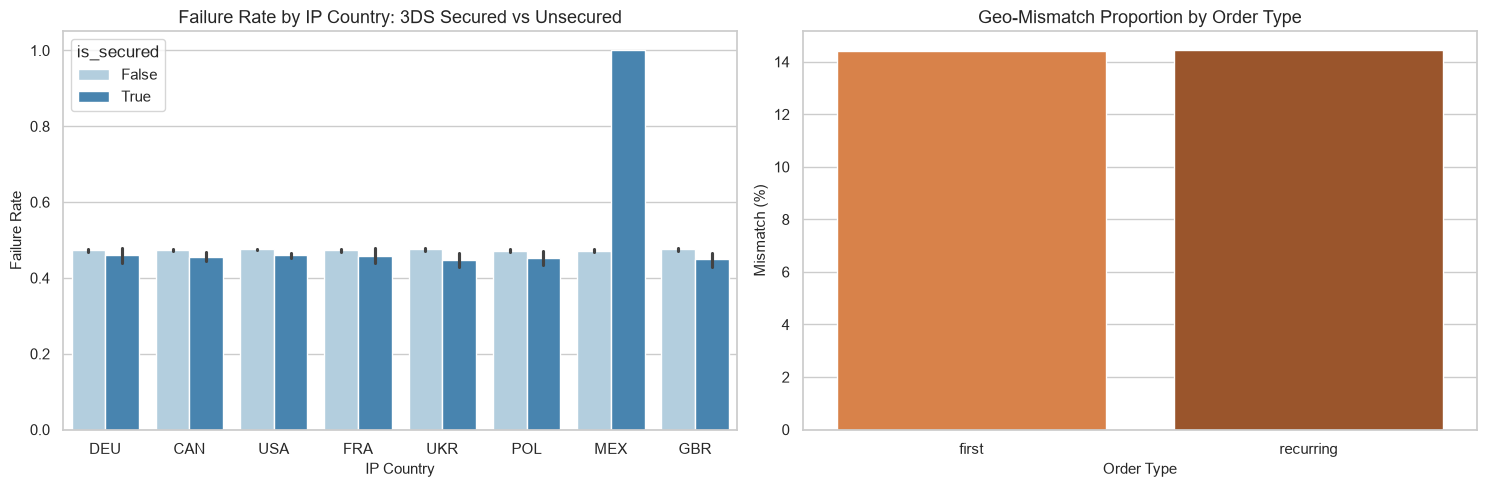

In [45]:
data['is_geo_mismatch'] = data['ip_country'] != data['bin_country']

geo_summary = data.groupby(['is_geo_mismatch', 'is_secured']).agg(
    volume=('order_id', 'count'),
    failure_rate=('is_failed', 'mean'),
    refund_rate=('has_refund', 'mean'),
    avg_amount_usd=('amount_usd', 'mean')
).reset_index()

geo_summary['Volume Pct (%)'] = (geo_summary['volume'] / len(data) * 100).round(2)
geo_summary['Failure Rate (%)'] = (geo_summary['failure_rate'] * 100).round(2)
geo_summary['Refund Rate (%)'] = (geo_summary['refund_rate'] * 100).round(2)
print(geo_summary[['is_geo_mismatch', 'is_secured', 'volume', 'Volume Pct (%)', 'Failure Rate (%)', 'Refund Rate (%)', 'avg_amount_usd']].round(2).to_string(index=False))

top_ips = data['ip_country'].value_counts().head(8).index
data_top_ip = data[data['ip_country'].isin(top_ips)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=data_top_ip, x='ip_country', y='is_failed', hue='is_secured', ax=axes[0], palette='Blues')
axes[0].set_title('Failure Rate by IP Country: 3DS Secured vs Unsecured')
axes[0].set_ylabel('Failure Rate')
axes[0].set_xlabel('IP Country')

mismatch_order = data.groupby('order_type')['is_geo_mismatch'].mean().reset_index()
mismatch_order['Mismatch (%)'] = mismatch_order['is_geo_mismatch'] * 100
sns.barplot(data=mismatch_order, x='order_type', y='Mismatch (%)', ax=axes[1], palette='Oranges_d')
axes[1].set_title('Geo-Mismatch Proportion by Order Type')
axes[1].set_ylabel('Mismatch (%)')
axes[1].set_xlabel('Order Type')

plt.tight_layout()
plt.show()
